# Optimizers


## Optimizer Comparison

* Setting up a fully connected neural network model using `PyTorch`. It is designed for classifying CIFAR10 images. The model has the following layers:
    * Layer1: input_dimension --> 256
    * Layer2: 256 --> 128
    * Layer3: 128 --> 10
    * Use ReLU as your non-linear activation function
* Monitoring the learning (loss-function) for different optimizers. Using `PyTorch`'s implementations for each:
    * SGD (with learning rates [0.1, 0.01, 0.001])
    * SGD (with learning rates [0.1, 0.01, 0.001] and 0.9 momentum)
    * Adam
    * AdamW
    * RMSprop

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


class SimpleFC(nn.Module):
    def __init__(self, input_dim=32*32*3, hidden1=256, hidden2=128, num_classes=10, p_drop=0.2):
        super(SimpleFC, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)



def get_optimizer(params, opt_name, lr=1e-3, momentum=0.0, weight_decay=0.0):
    opt_name = opt_name.lower()

    if opt_name == "sgd":
        return optim.SGD(params, lr=lr, weight_decay=weight_decay)
    if opt_name == "sgd_mom":
        return optim.SGD(params, lr=lr, momentum=momentum, weight_decay=weight_decay)
    if opt_name == "adam":
        return optim.Adam(params, lr=lr, weight_decay=weight_decay)
    if opt_name == "adamw":
        return optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    if opt_name == "rmsprop":
        return optim.RMSprop(params, lr=lr, weight_decay=weight_decay)

    raise ValueError(f"Unknown optimizer: {opt_name}")



def load_data(batch_size=32):  # Set batch size according to your machine
    """Load CIFAR-10 dataset."""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2470, 0.2435, 0.2616)
        )
    ])

    train_dataset = datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=transform
    )
    test_dataset = datasets.CIFAR10(
        root="./data",
        train=False,
        download=True,
        transform=transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, test_loader


def train(model, train_loader, optimizer, criterion, device, epochs=5):
    model.train()
    epoch_losses = []

    for epoch in range(epochs):
        running_loss = 0.0
        n_samples = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            n_samples += batch_size

        epoch_loss = running_loss / n_samples
        epoch_losses.append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs} - train loss: {epoch_loss:.4f}")

    return epoch_losses


@torch.no_grad()
def test(model, test_loader, criterion, device):
    """Evaluate on test set."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc


Using device: cpu


=== SGD lr=0.1 ===
Epoch 1/30 - train loss: 1.7557
Epoch 2/30 - train loss: 1.5671
Epoch 3/30 - train loss: 1.4868
Epoch 4/30 - train loss: 1.4324
Epoch 5/30 - train loss: 1.3885
Epoch 6/30 - train loss: 1.3543
Epoch 7/30 - train loss: 1.3276
Epoch 8/30 - train loss: 1.2929
Epoch 9/30 - train loss: 1.2700
Epoch 10/30 - train loss: 1.2517
Epoch 11/30 - train loss: 1.2325
Epoch 12/30 - train loss: 1.2096
Epoch 13/30 - train loss: 1.1956
Epoch 14/30 - train loss: 1.1746
Epoch 15/30 - train loss: 1.1629
Epoch 16/30 - train loss: 1.1482
Epoch 17/30 - train loss: 1.1299
Epoch 18/30 - train loss: 1.1207
Epoch 19/30 - train loss: 1.1089
Epoch 20/30 - train loss: 1.0962
Epoch 21/30 - train loss: 1.0862
Epoch 22/30 - train loss: 1.0781
Epoch 23/30 - train loss: 1.0673
Epoch 24/30 - train loss: 1.0581
Epoch 25/30 - train loss: 1.0478
Epoch 26/30 - train loss: 1.0418
Epoch 27/30 - train loss: 1.0334
Epoch 28/30 - train loss: 1.0230
Epoch 29/30 - train loss: 1.0167
Epoch 30/30 -

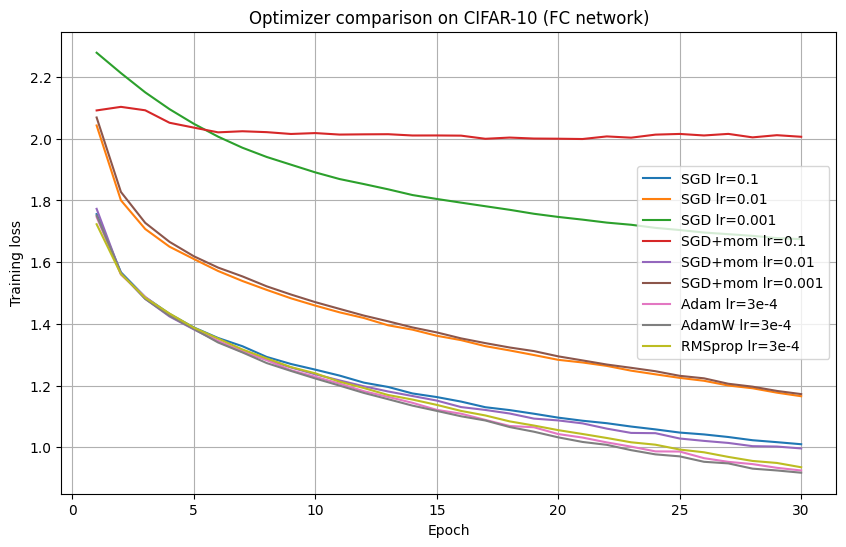

In [ ]:
# Setup - use CPU for simplicity
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}\n")

torch.manual_seed(0)

# Load data
batch_size = 128  # adjust if needed for your GPU/CPU
train_loader, test_loader = load_data(batch_size=batch_size)

criterion = nn.CrossEntropyLoss()

configs = [
    ("SGD lr=0.1",        dict(opt_name="sgd",     lr=0.1,   weight_decay=5e-4)),
    ("SGD lr=0.01",       dict(opt_name="sgd",     lr=0.01,  weight_decay=5e-4)),
    ("SGD lr=0.001",      dict(opt_name="sgd",     lr=0.001, weight_decay=5e-4)),

    # Keep it for the required comparison, but it may be unstable:
    ("SGD+mom lr=0.1",    dict(opt_name="sgd_mom", lr=0.1,   momentum=0.9, weight_decay=5e-4)),
    ("SGD+mom lr=0.01",   dict(opt_name="sgd_mom", lr=0.01,  momentum=0.9, weight_decay=5e-4)),
    ("SGD+mom lr=0.001",  dict(opt_name="sgd_mom", lr=0.001, momentum=0.9, weight_decay=5e-4)),

    # Tuned down LR + add decay for better generalization/calibration:
    ("Adam lr=3e-4",      dict(opt_name="adam",    lr=3e-4,  weight_decay=1e-4)),
    ("AdamW lr=3e-4",     dict(opt_name="adamw",   lr=3e-4,  weight_decay=1e-2)),
    ("RMSprop lr=3e-4",   dict(opt_name="rmsprop", lr=3e-4,  weight_decay=1e-4)),
]


epochs = 30  # often enough with dropout/decay; increase to 40 if you want
all_losses = {}
results = []

best_acc = -1.0
best_label = None
best_cfg = None
best_state_dict = None

for label, cfg in configs:
    print(f"\n=== {label} ===")
    model = SimpleFC(p_drop=0.2).to(device)
    optimizer = get_optimizer(model.parameters(), **cfg)

    losses = train(model, train_loader, optimizer, criterion, device, epochs=epochs)
    test_loss, test_acc = test(model, test_loader, criterion, device)

    print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc*100:.2f}%")

    all_losses[label] = losses
    results.append({
        "optimizer": label,
        "train_loss_last_epoch": float(losses[-1]),
        "test_loss": float(test_loss),
        "test_acc": float(test_acc),
    })

    if test_acc > best_acc:
        best_acc = test_acc
        best_label = label
        best_cfg = cfg
        best_state_dict = {k: v.detach().cpu() for k, v in model.state_dict().items()}


# Plot training loss curves
plt.figure(figsize=(10, 6))
for label, losses in all_losses.items():
    plt.plot(range(1, epochs + 1), losses, label=label)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Optimizer comparison on CIFAR-10 (FC network)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import os, json

# Sort and print results collected in cell 2 (NO retraining)
results_sorted = sorted(results, key=lambda x: x["test_acc"], reverse=True)

print("\nFinal metrics (sorted by test accuracy):")
print(f"{'Optimizer':25s} | {'TrainLoss(last)':>14s} | {'TestLoss':>8s} | {'TestAcc(%)':>10s}")
print("-" * 70)
for r in results_sorted:
    print(f"{r['optimizer'][:25]:25s} | {r['train_loss_last_epoch']:14.4f} | {r['test_loss']:8.4f} | {r['test_acc']*100:10.2f}")

print("\nBest run:")
print(f"- Optimizer: {best_label}")
print(f"- Test accuracy: {best_acc*100:.2f}%")
print(f"- Config dict: {best_cfg}")

# Save best checkpoint
os.makedirs("checkpoints", exist_ok=True)
ckpt_path = os.path.join("checkpoints", "best_model.pt")

torch.save(
    {
        "model_class": "SimpleFC",
        "best_label": best_label,
        "best_cfg": best_cfg,
        "epochs": epochs,
        "state_dict": best_state_dict,
        "best_acc": float(best_acc),
    },
    ckpt_path,
)

# Save results table
results_path = os.path.join("checkpoints", "all_results.json")
with open(results_path, "w") as f:
    json.dump(
        {
            "epochs": epochs,
            "batch_size": getattr(train_loader, "batch_size", None),
            "results_sorted": results_sorted,
            "best": {"label": best_label, "acc": float(best_acc), "cfg": best_cfg},
        },
        f,
        indent=2,
    )

print(f"\nSaved best checkpoint to: {ckpt_path}")
print(f"Saved full results to: {results_path}")



Final metrics (sorted by test accuracy):
Optimizer                 | TrainLoss(last) | TestLoss | TestAcc(%)
----------------------------------------------------------------------
RMSprop lr=3e-4           |         0.9354 |   1.2827 |      56.20
AdamW lr=3e-4             |         0.9177 |   1.2863 |      55.96
Adam lr=3e-4              |         0.9249 |   1.2711 |      55.84
SGD+mom lr=0.01           |         0.9964 |   1.2758 |      55.42
SGD lr=0.1                |         1.0100 |   1.2986 |      55.24
SGD+mom lr=0.001          |         1.1725 |   1.2857 |      55.06
SGD lr=0.01               |         1.1656 |   1.2842 |      54.93
SGD lr=0.001              |         1.6745 |   1.6263 |      42.99
SGD+mom lr=0.1            |         2.0064 |   1.9950 |      24.66

Best run:
- Optimizer: RMSprop lr=3e-4
- Test accuracy: 56.20%
- Config dict: {'opt_name': 'rmsprop', 'lr': 0.0003, 'weight_decay': 0.0001}

Saved best checkpoint to: checkpoints/best_model.pt
Saved full results to: